## 1 Create Grid

In [1]:
# Code block 0.1

# Import some non-landlab libraries
import numpy as np
import matplotlib as mpl

# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler
from landlab.plot.graph import plot_graph

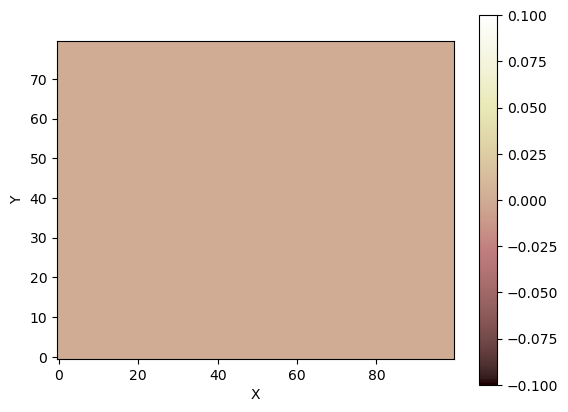

In [2]:
num_rows = 80  # number of grid rows
num_cols = 100  # number of grid columns
dxy = 1  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0

zr = mg.add_zeros("topographic__elevation", at="node")
# zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

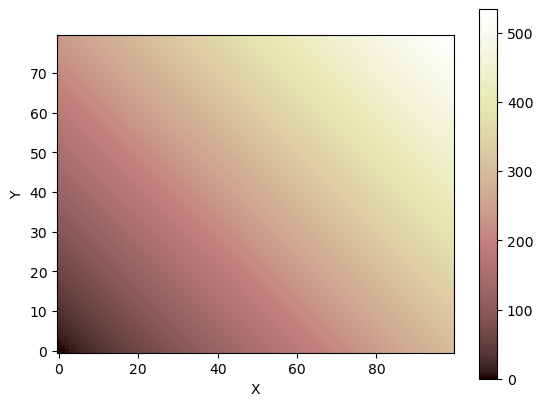

In [3]:
# add a diagonal ramp: low in SW, high in NE
zr += (mg.x_of_node + mg.y_of_node) * 3

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

In [4]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)

# find the node at (0, 0) — this is node ID 0 for a standard RasterModelGrid
outlet_node = mg.grid_coords_to_node_id(0, 0) if hasattr(mg, "grid_coords_to_node_id") else 0
# (simplest and most reliable: node (0,0) is always node ID 0)
outlet_node = 0

# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

In [5]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 1e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [6]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 623.1178976895521
model run time 200000
maximum elevation 716.9293439195643
model run time 300000
maximum elevation 808.6634939855526
model run time 400000
maximum elevation 895.1835642667108
model run time 500000
maximum elevation 973.4718543015758
model run time 600000
maximum elevation 1047.1552709530004
model run time 700000
maximum elevation 1118.1496402278165
model run time 800000
maximum elevation 1190.6203508517758
model run time 900000
maximum elevation 1253.2271889512463
model run time 1000000
maximum elevation 1285.316080374423


##### Visualize the topography

##### Print all the Fields in the Grid

In [7]:
mg.at_node.keys()

['topographic__elevation',
 'water__unit_flux_in',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__sink_flag',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope']

In [8]:
mg.at_node["topographic__elevation"]

array([  0.,   3.,   6., ..., 528., 531., 534.], shape=(8000,))

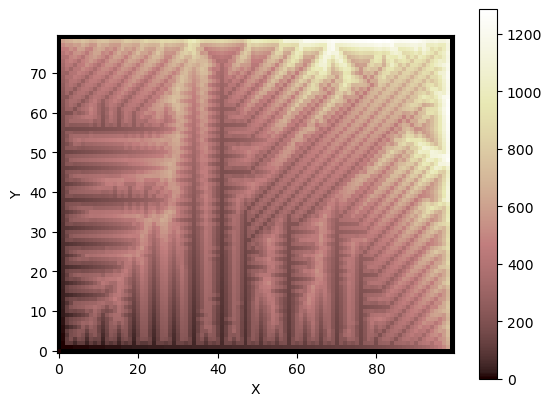

In [9]:
imshow_grid(mg, "topographic__elevation")

Text(0.5, 1.0, 'log10 of drainage area, time = 1000000')

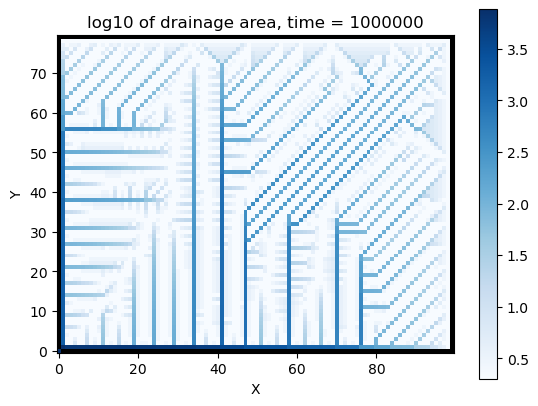

In [10]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

### Visualize the topography

##### Print all the Fields in the Grid

In [62]:
mg.at_node.keys()

['topographic__elevation',
 'water__unit_flux_in',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__sink_flag',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope']

In [63]:
mg.at_node["topographic__elevation"]

array([0.00054881, 0.00071519, 0.00060276, ..., 0.00044646, 0.00036013,
       0.00062589], shape=(20000,))

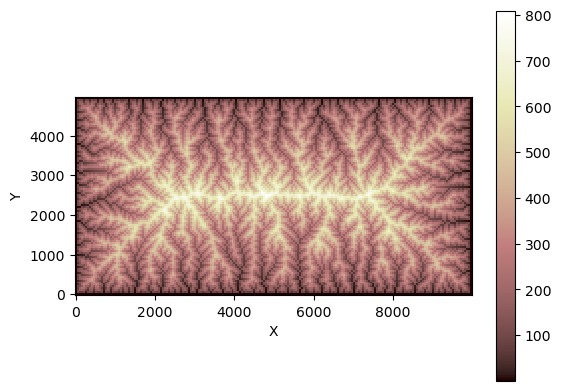

In [64]:
imshow_grid(mg, "topographic__elevation")

## 2 Create Channels

## 3 Erosion Deposition Component

## 4 Precipitation Scenarios